In [1]:
import sys
print(sys.executable)
print("Kernel working")

c:\Users\ZAID-PC\sepsis-early-warning-system\venv\Scripts\python.exe
Kernel working


Cell 1 — Import Libraries

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

print("✅ All libraries loaded successfully")
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")

✅ All libraries loaded successfully
pandas  : 2.3.3
numpy   : 2.4.3


Cell 2 — Load All .psv Files

In [3]:
def load_psv_folder(folder_path, label):
    """Load all .psv patient files from a folder into one DataFrame."""
    all_dfs = []
    files = sorted([f for f in os.listdir(folder_path) if f.endswith('.psv')])
    print(f"Loading {label}: {len(files)} patient files found...")

    for filename in files:
        filepath = os.path.join(folder_path, filename)
        df = pd.read_csv(filepath, sep='|')
        df['PatientID'] = filename.replace('.psv', '')
        df['Hour'] = range(len(df))
        all_dfs.append(df)

    combined = pd.concat(all_dfs, ignore_index=True)
    print(f"✅ {label} loaded: {combined.shape[0]:,} rows | {combined['PatientID'].nunique():,} patients")
    return combined

# ── UPDATE THESE PATHS to match your folder structure ──────────
setA_path = '../data/setA'
setB_path = '../data/setB'

df_A = load_psv_folder(setA_path, 'Set A')
df_B = load_psv_folder(setB_path, 'Set B')

# Combine both
df = pd.concat([df_A, df_B], ignore_index=True)

print(f"\n{'='*40}")
print(f"TOTAL COMBINED DATASET")
print(f"{'='*40}")
print(f"Total rows    : {df.shape[0]:,}")
print(f"Total columns : {df.shape[1]}")
print(f"Total patients: {df['PatientID'].nunique():,}")
print(f"{'='*40}")

Loading Set A: 20336 patient files found...
✅ Set A loaded: 790,215 rows | 20,336 patients
Loading Set B: 20000 patient files found...
✅ Set B loaded: 761,995 rows | 20,000 patients

TOTAL COMBINED DATASET
Total rows    : 1,552,210
Total columns : 43
Total patients: 40,336


Cell 3 — Preview the Data

In [10]:
print("FIRST 3 ROWS:")
display(df.head(50))

print("\nCOLUMN NAMES:")
print(list(df.columns))

print("\nDATA TYPES:")
print(df.dtypes.to_string())

FIRST 3 ROWS:


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,PatientID,Hour
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0,p000001,0
1,97.00,95.00,NaN,98.00,75.33,NaN,19.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0,p000001,1
2,89.00,99.00,NaN,122.00,86.00,NaN,22.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0,p000001,2
3,90.00,95.00,NaN,NaN,NaN,NaN,30.00,NaN,24.00,NaN,NaN,7.36,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0,p000001,3
4,103.00,88.50,NaN,122.00,91.33,NaN,24.50,NaN,NaN,NaN,0.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0,p000001,4
5,110.00,91.00,NaN,NaN,NaN,NaN,22.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,6,0,p000001,5
6,108.00,92.00,36.11,123.00,77.00,NaN,29.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,7,0,p000001,6
7,106.00,90.50,NaN,93.00,76.33,NaN,29.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,8,0,p000001,7
8,104.00,95.00,NaN,133.00,88.33,NaN,26.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,9,0,p000001,8
9,102.00,91.00,NaN,134.00,87.33,NaN,30.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,10,0,p000001,9



COLUMN NAMES:
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'PatientID', 'Hour']

DATA TYPES:
HR                  float64
O2Sat               float64
Temp                float64
SBP                 float64
MAP                 float64
DBP                 float64
Resp                float64
EtCO2               float64
BaseExcess          float64
HCO3                float64
FiO2                float64
pH                  float64
PaCO2               float64
SaO2                float64
AST                 float64
BUN                 float64
Alkalinephos        float64
Calcium             float64
Chloride            fl

Cell 4 — Missing Values Analysis

MISSING VALUES (% of total rows):

Bilirubin_direct   99.80
Fibrinogen         99.30
TroponinI          99.00
Bilirubin_total    98.50
Alkalinephos       98.40
AST                98.40
Lactate            97.30
PTT                97.10
SaO2               96.50
EtCO2              96.30
Phosphate          96.00
HCO3               95.80
Chloride           95.50
BaseExcess         94.60
PaCO2              94.40
Calcium            94.10
Platelets          94.10
Creatinine         93.90
Magnesium          93.70
WBC                93.60
BUN                93.10
pH                 93.10
Hgb                92.60
FiO2               91.70
Hct                91.10
Potassium          90.70
Glucose            82.90
Temp               66.20
Unit2              39.40
Unit1              39.40
DBP                31.30
Resp               15.40
SBP                14.60
O2Sat              13.10
MAP                12.50
HR                  9.90


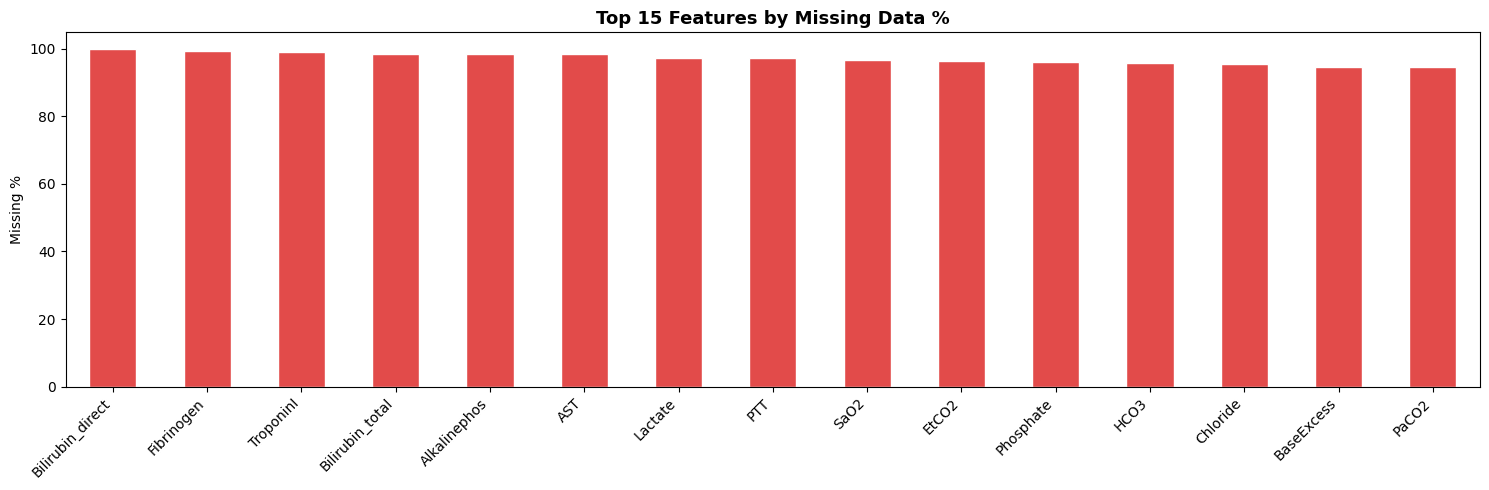

✅ Chart saved to outputs/


In [15]:
missing = (df.isnull().sum() / len(df) * 100).round(1)
missing = missing[missing > 0].sort_values(ascending=False)

print("MISSING VALUES (% of total rows):\n")
print(missing.to_string())

# Visualize top 15 missing
plt.figure(figsize=(15, 5))
missing.head(15).plot(kind='bar', color='#E24B4A', edgecolor='white')
plt.title('Top 15 Features by Missing Data %', fontsize=13, fontweight='bold')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/01_missing_values.png', dpi=150)
plt.show()
print("✅ Chart saved to outputs/")

Cell 5 — Sepsis Distribution

SEPSIS DISTRIBUTION
Total patients     : 40,336
Sepsis patients    : 2,932  (7.3%)
Non-sepsis patients: 37,404  (92.7%)
Imbalance ratio    : 1 : 12

⚠️  This imbalance is why we CANNOT use accuracy as metric.
   We will use AUROC + SMOTE to handle this properly in Week 2.


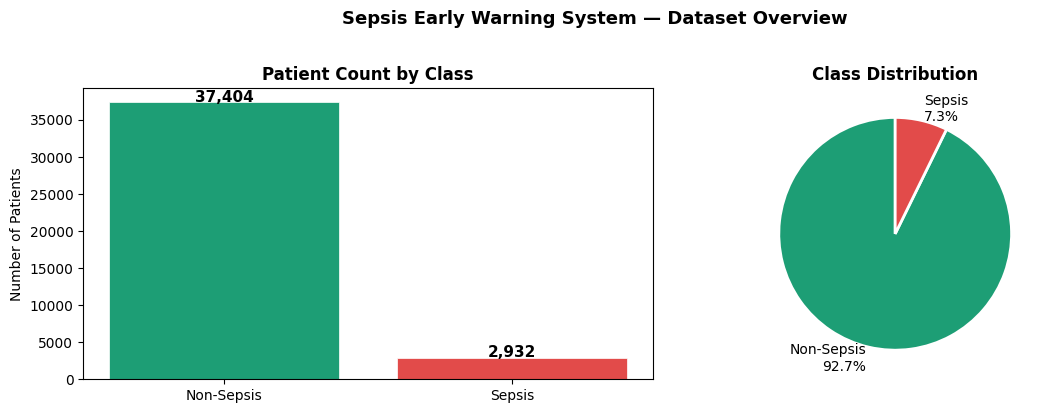

✅ Chart saved to outputs/


In [6]:
# How many patients have sepsis?
patient_summary = df.groupby('PatientID')['SepsisLabel'].max().reset_index()
patient_summary.columns = ['PatientID', 'HasSepsis']

total     = len(patient_summary)
sepsis    = patient_summary['HasSepsis'].sum()
no_sepsis = total - sepsis
pct       = round(sepsis / total * 100, 1)

print(f"{'='*40}")
print(f"SEPSIS DISTRIBUTION")
print(f"{'='*40}")
print(f"Total patients     : {total:,}")
print(f"Sepsis patients    : {int(sepsis):,}  ({pct}%)")
print(f"Non-sepsis patients: {int(no_sepsis):,}  ({100-pct}%)")
print(f"Imbalance ratio    : 1 : {int(no_sepsis/sepsis)}")
print(f"{'='*40}")
print("\n⚠️  This imbalance is why we CANNOT use accuracy as metric.")
print("   We will use AUROC + SMOTE to handle this properly in Week 2.")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Non-Sepsis', 'Sepsis'], [no_sepsis, sepsis],
            color=['#1D9E75', '#E24B4A'], edgecolor='white', linewidth=0.5)
axes[0].set_title('Patient Count by Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate([no_sepsis, sepsis]):
    axes[0].text(i, v + 30, f'{int(v):,}', ha='center', fontweight='bold', fontsize=11)

# Pie chart
axes[1].pie([no_sepsis, sepsis],
            labels=[f'Non-Sepsis\n{100-pct}%', f'Sepsis\n{pct}%'],
            colors=['#1D9E75', '#E24B4A'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution', fontsize=12, fontweight='bold')

plt.suptitle('Sepsis Early Warning System — Dataset Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/01_sepsis_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to outputs/")

Cell 6 — Vital Signs Distribution

Key features available in dataset: ['HR', 'Temp', 'Resp', 'O2Sat', 'SBP', 'MAP', 'DBP', 'WBC']


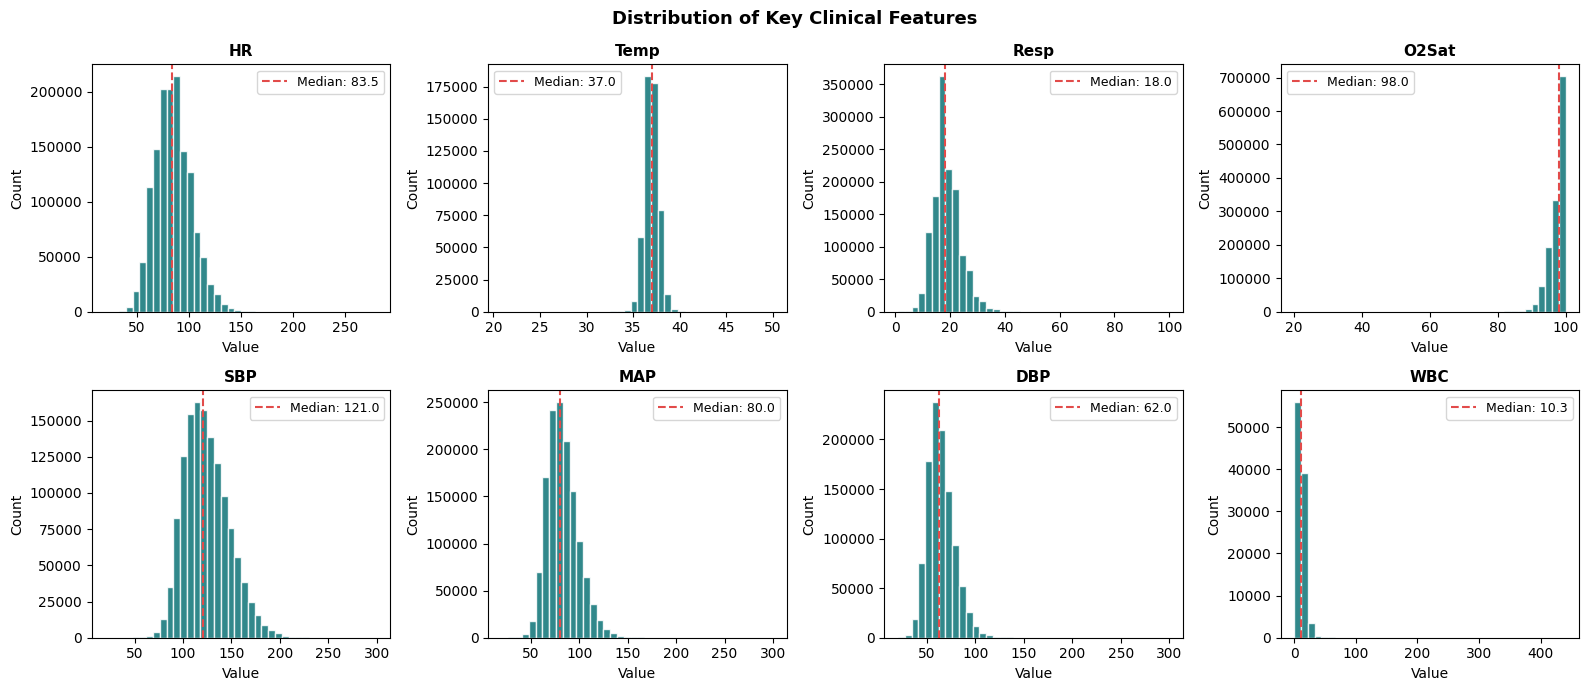

✅ Chart saved to outputs/


In [7]:
# These are the 8 key clinical features we will use for prediction
key_features = ['HR', 'Temp', 'Resp', 'O2Sat', 'SBP', 'MAP', 'DBP', 'WBC']
available    = [f for f in key_features if f in df.columns]

print(f"Key features available in dataset: {available}")

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(available):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='#0D7377', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].axvline(data.median(), color='#E24B4A', linestyle='--',
                    linewidth=1.5, label=f'Median: {data.median():.1f}')
    axes[i].legend(fontsize=9)

for j in range(len(available), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Key Clinical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/01_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved to outputs/")

Cell 7 — Summary Statistics

In [8]:
print("SUMMARY STATISTICS FOR KEY FEATURES:\n")
summary = df[available + ['SepsisLabel']].describe().T
display(summary)

# Save to CSV for your report
summary.to_csv('../outputs/01_summary_statistics.csv')
print("\n✅ Summary statistics saved to outputs/")

print(f"\n{'='*40}")
print("WEEK 1 CHECKPOINT — CONFIRM THESE:")
print(f"{'='*40}")
print(f"Total rows      : {df.shape[0]:,}  (expected: ~1.5M)")
print(f"Total patients  : {df['PatientID'].nunique():,}  (expected: ~40,000)")
print(f"Sepsis rate     : {pct}%  (expected: ~7-8%)")
print(f"Columns         : {df.shape[1]}  (expected: ~42)")
print(f"{'='*40}")

SUMMARY STATISTICS FOR KEY FEATURES:



,count,mean,std,min,25%,50%,75%,max
HR,1398811.00,84.58,17.33,20.00,72.00,83.50,95.50,280.00
Temp,525226.00,36.98,0.77,20.90,36.50,37.00,37.50,50.00
Resp,1313875.00,18.73,5.10,1.00,15.00,18.00,21.50,100.00
O2Sat,1349474.00,97.19,2.94,20.00,96.00,98.00,99.50,100.00
SBP,1325945.00,123.75,23.23,20.00,107.00,121.00,138.00,300.00
MAP,1358940.00,82.40,16.34,20.00,71.00,80.00,92.00,300.00
DBP,1065656.00,63.83,13.96,20.00,54.00,62.00,72.00,300.00
WBC,99447.00,11.45,7.73,0.10,7.60,10.30,13.80,440.00
SepsisLabel,1552210.00,0.02,0.13,0.00,0.00,0.00,0.00,1.00



✅ Summary statistics saved to outputs/

WEEK 1 CHECKPOINT — CONFIRM THESE:
Total rows      : 1,552,210  (expected: ~1.5M)
Total patients  : 40,336  (expected: ~40,000)
Sepsis rate     : 7.3%  (expected: ~7-8%)
Columns         : 43  (expected: ~42)


Cell 8 — Save the Combined Dataset

In [9]:
# Save the full combined dataframe so we don't reload every time
output_path = '../data/combined_dataset.parquet'
df.to_parquet(output_path, index=False)
print(f"✅ Dataset saved to {output_path}")
print(f"   File size: {os.path.getsize(output_path) / 1024 / 1024:.1f} MB")
print("\n🎯 Week 2 Step 1 COMPLETE — Notebook ready to push to GitHub")

✅ Dataset saved to ../data/combined_dataset.parquet
   File size: 16.5 MB

🎯 Week 2 Step 1 COMPLETE — Notebook ready to push to GitHub
